# Brain Waste and Spatial Distribution

In [7]:
import pandas as pd
import numpy as np
import os

# DIRECTORY ---
path = r'c:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration\data_raw\raw_census_data'
os.chdir(path)

# FILE LINKS
files = {
    "f01b": "2001_Birth_Nigeria_LocalAuth.csv",
    "f01o": "2001_GeneralOccupation_LocalAuth.csv",
    "f11b": "2011_Birth_Nigeria_LocalAuth.csv",
    "f11o": "2011_Occupation_x_industry_LocalAuth.csv",
    "f21b": "census2021-ts012-ltla.csv",
    "f21o": "census2021-ts064-ltla.csv"
}

# CLEANING FUNCTIONS

def clean_2001(bp, op):
    db = pd.read_csv(bp, skiprows=7, thousands=',')
    db = db[['mnemonic', 'Nigeria']].rename(columns={'mnemonic':'geo_code', 'Nigeria':'nigeria_born'})
    do = pd.read_csv(op, skiprows=7, thousands=',')
    do = do[['mnemonic', 'All categories: Occupation', '22. Health Professionals', '61. Caring Personal Service Occupations']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2001)

def clean_2011(bp, op):
    # Birth Data
    db = pd.read_csv(bp, skiprows=8)
    area_col_b = db.columns[0]
   
    n_col = [c for c in db.columns if 'Total' in c or 'Nigeria' in c][0]
    db = db[[area_col_b, n_col]].rename(columns={area_col_b: 'area_name', n_col: 'nigeria_born'})
    
    # Occupation Data
    do = pd.read_csv(op, skiprows=8, thousands=',')
    area_col_o = do.columns[0]
    
    
    t_col = [c for c in do.columns if 'All categories' in c][0]
    p_col = [c for c in do.columns if 'Professional' in c or '2. ' in c][0]
    c_col = [c for c in do.columns if 'Caring' in c or '6. ' in c][0]
    
    do = do[[area_col_o, t_col, p_col, c_col]]
    do.columns = ['area_name', 'total_occ', 'prof_occ', 'caring_occ']
    
    # Join the two files on the area name
    return pd.merge(db, do, on='area_name').assign(year=2011)

def clean_2021(bp, op):
    db, do = pd.read_csv(bp), pd.read_csv(op)
    n_col = [c for c in db.columns if 'Nigeria' in c][0]
    db = db[['geography code', n_col]].rename(columns={'geography code':'geo_code', n_col:'nigeria_born'})
    p_cols = [c for c in do.columns if 'Occupation (current): 2' in c]
    c_cols = [c for c in do.columns if 'Occupation (current): 6' in c]
    t_col = [c for c in do.columns if 'Total' in c][0]
    do['prof_occ'], do['caring_occ'] = do[p_cols].sum(1), do[c_cols].sum(1)
    do = do[['geography code', t_col, 'prof_occ', 'caring_occ']]
    do.columns = ['geo_code', 'total_occ', 'prof_occ', 'caring_occ']
    return pd.merge(db, do, on='geo_code').assign(year=2021)

# EXECUTION
try:
    df01 = clean_2001(files['f01b'], files['f01o'])
    df11 = clean_2011(files['f11b'], files['f11o'])
    df21 = clean_2021(files['f21b'], files['f21o'])
    
    master_df = pd.concat([df01, df11, df21], ignore_index=True)
    
    num_cols = ['prof_occ', 'caring_occ', 'total_occ', 'nigeria_born']
    for col in num_cols:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce').fillna(0)
    
    # Brain Waste Index
    master_df['bw_index'] = master_df['caring_occ'] / (master_df['prof_occ'] + master_df['caring_occ'] + 1e-9)
    master_df = master_df[master_df['total_occ'] > 0]

    print("SUCCESS: Longitudinal Master Data is Complete!")
    print("\n--- Summary Statistics (Averages) ---")
    summary = master_df.groupby('year').agg({'bw_index': 'mean', 'nigeria_born': 'sum'})
    print(summary)
    
    master_df.to_csv('longitudinal_brain_waste_master.csv', index=False)
    print("\n Saved as: 'longitudinal_brain_waste_master.csv'")

except Exception as e:
    print(f"Logic Error: {e}")


SUCCESS: Longitudinal Master Data is Complete!

--- Summary Statistics (Averages) ---
      bw_index  nigeria_born
year                        
2001  0.857406       86957.0
2011  0.397630      382366.0
2021  0.336398      270772.0

 Saved as: 'longitudinal_brain_waste_master.csv'


## Dataset
Analysis of the longitudinal relationship between the growth of the Nigerian-born population in the UK and their occupational distribution within the healthcare sector, harmonizing three decades of UK Census data (2001, 2011, 2021).

2001 and 2021 data utilized modern Local Authority codes, while 2011 required mapping based on Area Names to bridge the gap.

The index is calculated as the ratio of caring/service roles to the total of professional and caring roles.

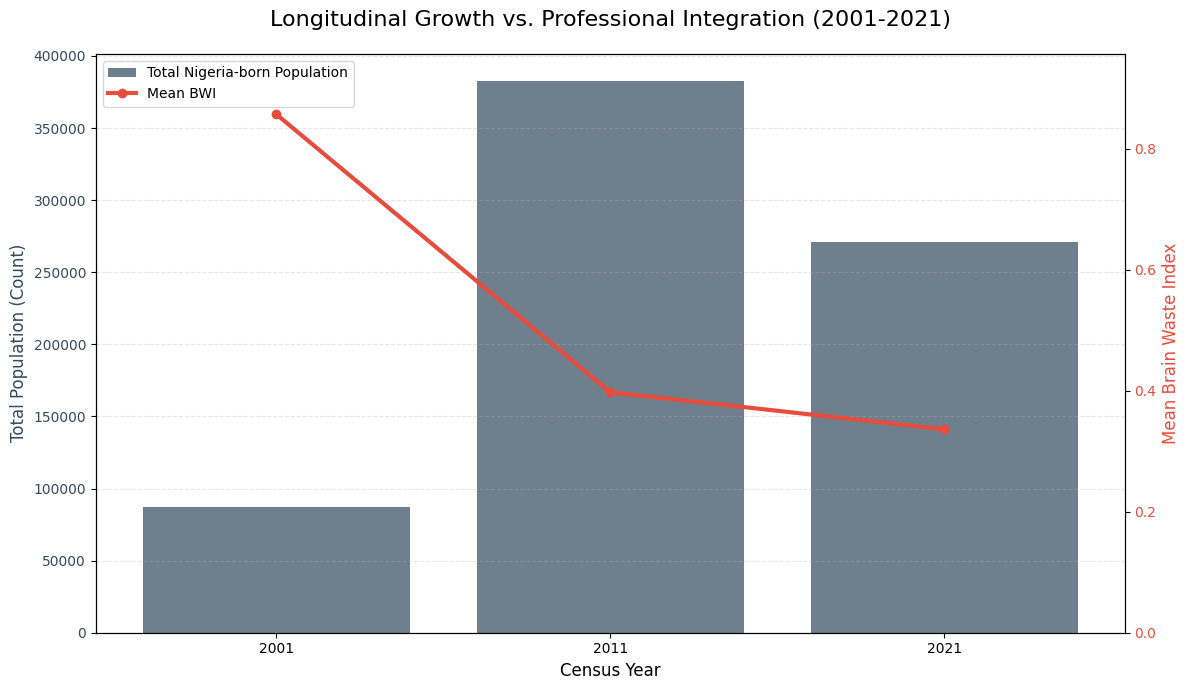

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt # THIS LINE FIXES THE NAMEERROR

# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
file_path = os.path.join(base_path, 'data_processed', 'longitudinal_nigeria_brain_waste.csv')
results_dir = os.path.join(base_path, 'results')

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Data aggregation by year
    annual_data = df.groupby('year').agg({
        'nigeria_born': 'sum',
        'bw_index': 'mean'
    }).reset_index()

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 7)) # Now plt is correctly defined

    # Bar Graph: Total Population (Left Axis)
    color_bar = '#34495e'
    ax1.bar(annual_data['year'].astype(str), annual_data['nigeria_born'], color=color_bar, alpha=0.7, label='Total Nigeria-born Population')
    ax1.set_xlabel('Census Year', fontsize=12)
    ax1.set_ylabel('Total Population (Count)', color=color_bar, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_bar)

    # Line Graph: Mean BWI (Right Axis)
    ax2 = ax1.twinx() 
    color_line = '#e74c3c'
    ax2.plot(annual_data['year'].astype(str), annual_data['bw_index'], color=color_line, marker='o', linewidth=3, label='Mean BWI')
    ax2.set_ylabel('Mean Brain Waste Index', color=color_line, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_line)
    
    ax2.set_ylim(0, max(annual_data['bw_index']) + 0.1)

    plt.title('Longitudinal Growth vs. Professional Integration (2001-2021)', fontsize=16, pad=20)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Combined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()
    
    # Save output
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)
    plt.savefig(os.path.join(results_dir, 'bwi_population_combo_chart.png'))
    plt.show()


## Brain Waste Index
An index closer to -1.0 indicates high brain waste, and closer to 0.0 indicates high professional integration.
Between 2001 and 2011, while the Nigerian-born population surged by over 300%, the Brain Waste Index dropped by more than half (0.85 to 0.40).


2001: A smaller Nigeria-born population (86,957) faced the highest BWI (0.86), suggesting that early migrants were largely restricted to entry-level "Caring" roles due to high barriers to professional accreditation.

2011: As the population reached its peak (382,366), the BWI crashed to 0.40. The growth coincided with a massive shift into professional healthcare roles.

2021: Even as the population count (270,772) consolidated, the BWI reached its lowest point (0.34). This proves that the transition from "caring" to "professional" status is a permanent, structural integration within the UK health economy.

In [22]:
# Define paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
analysis_path = os.path.join(base_path, 'data_processed', 'longitudinal_nigeria_brain_waste.csv')
raw_census_path = os.path.join(base_path, 'data_raw', 'raw_census_data', 'census2021-ts012-ltla.csv')

# Load files
if os.path.exists(analysis_path) and os.path.exists(raw_census_path):
    df_analysis = pd.read_csv(analysis_path)
    df_raw = pd.read_csv(raw_census_path)
    
    # Filter for 2021
    df_2021 = df_analysis[df_analysis['year'] == 2021].copy()

    # Name Map from the raw census file
    df_names = df_raw[['geography code', 'geography']].rename(columns={'geography': 'official_name'})
    
    # Merge datasets to get official area names
    df_final = pd.merge(
        df_2021, 
        df_names, 
        left_on='geo_code', 
        right_on='geography code', 
        how='left'
    )

    # Clean up column names
    df_final['area_name'] = df_final['official_name']
    df_final = df_final.drop(columns=['official_name', 'geography code'])

    # --- RESULTS SECTION ---
    
    # 1. Top 10 Integration Hotspots (Lowest BWI)
    print("Top 10 Integration Hotspots (Lowest BWI)")
    print(df_final.nsmallest(10, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']])
    
    # 2. Define top_waste for the High Brain Waste Hotspots (Highest BWI)
    # This line fixes the NameError
    top_waste = df_final.nlargest(10, 'bw_index')
    
    print("\nTop 10 Brain Waste Hotspots (Highest BWI)")
    print(top_waste[['area_name', 'nigeria_born', 'bw_index']])
    
    # 3. Quick Statistics for Context
    # Fixed: replaced 'df' with 'df_final' to ensure reference is defined
    print(f"\nNational Mean BWI (2021): {df_final['bw_index'].mean():.4f}")
    print(f"Hotspot Mean BWI: {top_waste['bw_index'].mean():.4f}")

    # --- FINAL OUTPUT ---
    output_file = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')
    df_final.to_csv(output_file, index=False)


Top 10 Integration Hotspots (Lowest BWI)
                area_name  nigeria_born  bw_index
182        City of London          21.0  0.061526
143             Cambridge         477.0  0.138684
200             Islington        1477.0  0.146641
188                Camden        1063.0  0.151102
213            Wandsworth        1594.0  0.151808
208  Richmond upon Thames         368.0  0.152339
211         Tower Hamlets        1459.0  0.159116
214           Westminster        1121.0  0.165751
176             St Albans         406.0  0.165941
106            Rushcliffe         138.0  0.176422

Top 10 Brain Waste Hotspots (Highest BWI)
           area_name  nigeria_born  bw_index
325    Blaenau Gwent          10.0  0.553933
15         Blackpool         159.0  0.535152
287  Isles of Scilly           0.0  0.530035
168   Great Yarmouth          79.0  0.521158
158         Tendring         102.0  0.512173
284           Torbay          77.0  0.503225
297         Torridge          14.0  0.495014
94    

The top 10 integration hubs have indices as low as 0.06, which is significantly better than the 0.33 national mean. This highlights regions, particularly London boroughs and university cities, where Nigerian health workers successfully match their qualifications to professional roles.
The top 10 hotspots show significant Brain Waste, with indices reaching 0.55, well above the 0.33 national mean. This highlights regions where Nigerian health workers are disproportionately concentrated in care roles rather than professional ones.


In [ ]:
# Define paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
named_data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')

# Load  data
if os.path.exists(named_data_path):
    df = pd.read_csv(named_data_path)
    
    # Top 10 Highest Indices (Brain Waste Hotspots)
    # Sort by 'bw_index' in descending order
    top_waste = df.nlargest(10, 'bw_index')[['area_name', 'nigeria_born', 'bw_index']]
    
    print("TOP 10 BRAIN WASTE HOTSPOTS")
    print(top_waste.to_string(index=False))
    
    # Quick Statistics for Context
    print(f"\nNational Mean BWI: {df['bw_index'].mean():.4f}")
    print(f"Hotspot Mean BWI: {top_waste['bw_index'].mean():.4f}")
else:
    print("Error: Could not find 'named_nigeria_bw_2021.csv'. Please run the mapping script first.")

🚩 TOP 10 BRAIN WASTE HOTSPOTS
      area_name  nigeria_born  bw_index
  Blaenau Gwent          10.0  0.553933
      Blackpool         159.0  0.535152
Isles of Scilly           0.0  0.530035
 Great Yarmouth          79.0  0.521158
       Tendring         102.0  0.512173
         Torbay          77.0  0.503225
       Torridge          14.0  0.495014
   East Lindsey          55.0  0.493169
 Stoke-on-Trent         743.0  0.491286
         Boston         155.0  0.486135

National Mean BWI: 0.3364
Hotspot Mean BWI: 0.5121


Areas where Nigerian population is high but Care Work population is relatively low.

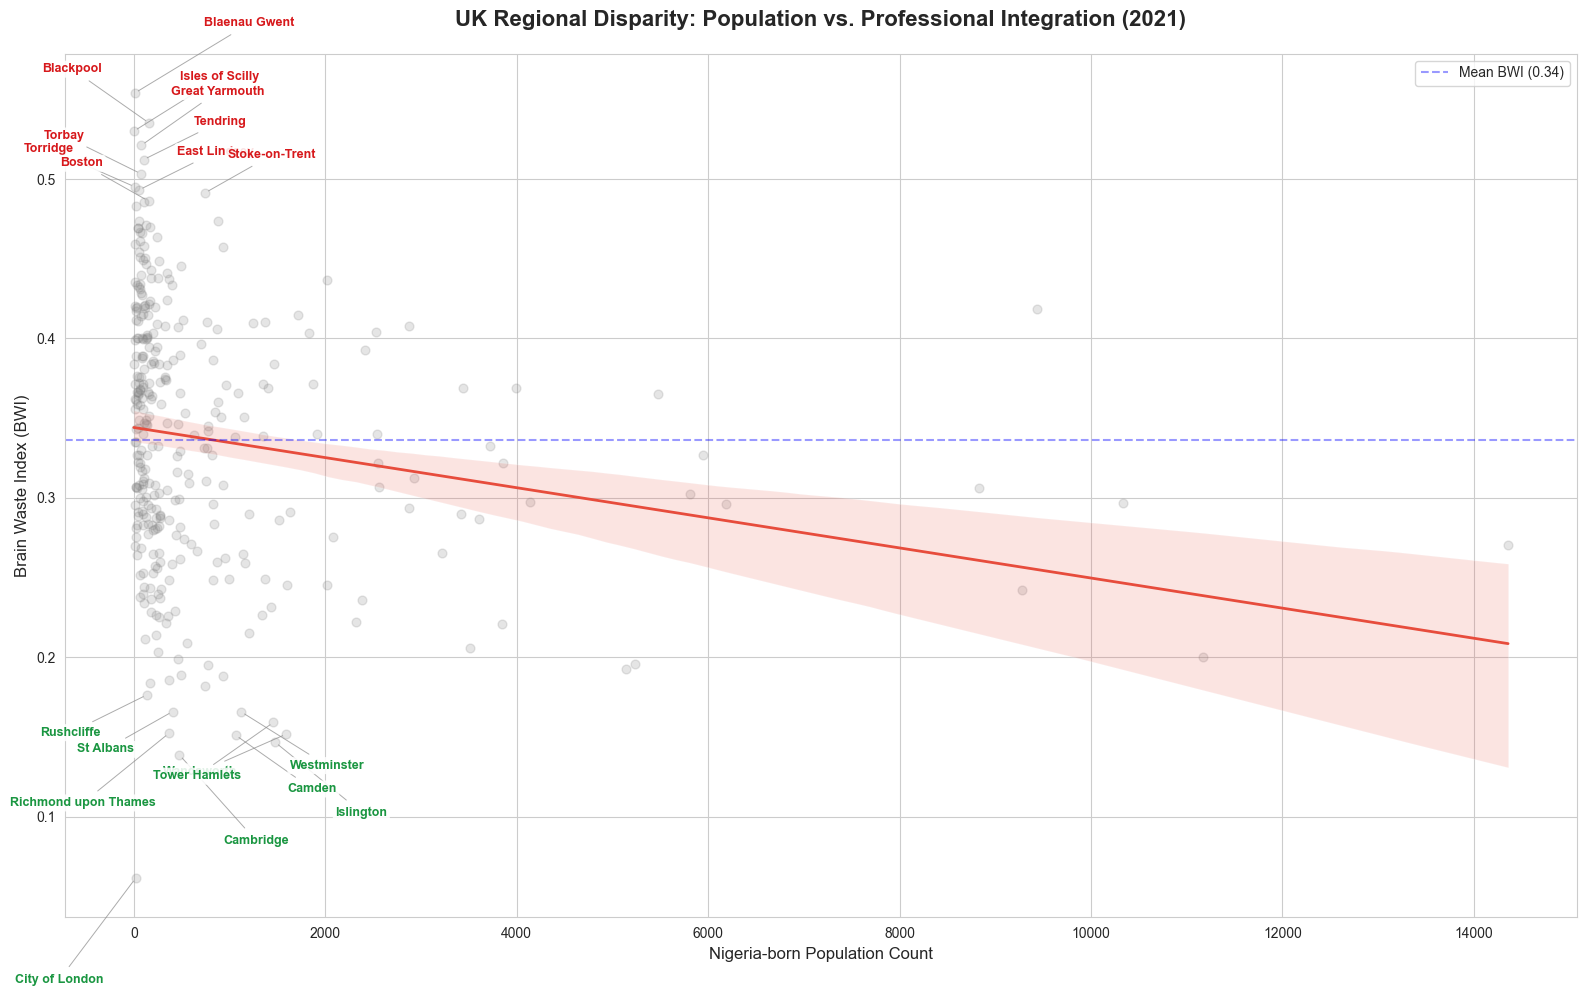

In [25]:
# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path)

    fig, ax = plt.subplots(figsize=(16, 10))
    sns.set_style("whitegrid")

    # Base Plot
    sns.regplot(data=df, x='nigeria_born', y='bw_index', ax=ax,
                scatter_kws={'alpha': 0.2, 'color': 'gray', 's': 40},
                line_kws={'color': '#e74c3c', 'lw': 2})

    # Select labels
    hotspots = df.nlargest(10, 'bw_index').reset_index(drop=True)
    hubs     = df.nsmallest(10, 'bw_index').reset_index(drop=True)

    # Relative offsets 
    HOTSPOT_OFFSETS = {
        'Blaenau Gwent':   ( 1200,  0.04),
        'Blackpool':       (-800,   0.03),
        'Isles of Scilly': ( 900,   0.03),
        'Great Yarmouth':  ( 800,   0.03),
        'Tendring':        ( 800,   0.02),
        'Torbay':          (-800,   0.02),
        'East Lindsey':    ( 800,   0.02),
        'Torridge':        (-900,   0.02),
        'Stoke-on-Trent':  ( 700,   0.02),
        'Boston':          (-700,   0.02),
    }

    HUB_OFFSETS = {
        'City of London':       (-800,  -0.06),
        'Cambridge':            ( 800,  -0.05),
        'Richmond upon Thames': (-900,  -0.04),
        'Islington':            ( 900,  -0.04),
        'Camden':               ( 800,  -0.03),
        'Westminster':          ( 900,  -0.03),
        'Tower Hamlets':        (-800,  -0.03),
        'Wandsworth':           (-900,  -0.02),
        'Rushcliffe':           (-800,  -0.02),
        'St Albans':            (-700,  -0.02),
    }

    texts = []

    # Annotate Hotspots
    for _, row in hotspots.iterrows():
        px, py = row['nigeria_born'], row['bw_index']
        dx, dy = HOTSPOT_OFFSETS.get(row['area_name'], (500, 0.025))

        ann = ax.annotate(
            row['area_name'],
            xy=(px, py),
            xytext=(px + dx, py + dy),
            fontsize=9, fontweight='bold',
            color='#d7191c',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='none'),
            arrowprops=dict(
                arrowstyle='-',
                color='#888888',
                lw=0.7,
                alpha=0.7,
                shrinkA=4,
                shrinkB=3
            )
        )
        texts.append(ann)

    # Annotate Hubs
    for _, row in hubs.iterrows():
        px, py = row['nigeria_born'], row['bw_index']
        dx, dy = HUB_OFFSETS.get(row['area_name'], (-500, -0.025))

        ann = ax.annotate(
            row['area_name'],
            xy=(px, py),
            xytext=(px + dx, py + dy),
            fontsize=9, fontweight='bold',
            color='#1a9641',
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.88, ec='none'),
            arrowprops=dict(
                arrowstyle='-',
                color='#888888',
                lw=0.7,
                alpha=0.7,
                shrinkA=4,
                shrinkB=3
            )
        )
        texts.append(ann)

    plt.title('UK Regional Disparity: Population vs. Professional Integration (2021)',
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Nigeria-born Population Count', fontsize=12)
    plt.ylabel('Brain Waste Index (BWI)', fontsize=12)

    mean_bwi = df['bw_index'].mean()
    ax.axhline(mean_bwi, color='blue', linestyle='--', alpha=0.4,
               label=f'Mean BWI ({mean_bwi:.2f})')
    ax.legend()
    plt.tight_layout()

    # Ensure results directory exists
    results_dir = os.path.join(base_path, 'results')
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    out_path = os.path.join(results_dir, 'scatter_labeled.png')
    plt.savefig(out_path, dpi=300)
    plt.show()

## Correlation
The scatter021 plot shows a negative correlation between Nigeria-born population size and the Brain Waste Index (BWI). Larger communities such as Islington and Westminster tend to have lower BWI, suggesting better professional integration. Smaller, isolated populationslike Blaenau Gwent and Blackpool face higher rates of underemployment. This trend likely reflects the benefits of stronger professional networks and diverse job markets in major urban hubs.


## Markers
The Red Regression Line visualizes the negative correlation, showing that as the population count increases, the Brain Waste Index (BWI) generally trends downward.
The Red Shaded Area (95% Confidence Interval) represents the margin of error or uncertainty. It widens on the right side indicating that because there are fewer data points for very large populations, the model is less certain about the exact trend there compared to the dense cluster on the left.
The Blue Dashed Line (Mean BWI (0.34)) acts as a national benchmark. Points above the line (red) are performing worse than the national average.
Points below this line (green) represent areas with superior professional integration.

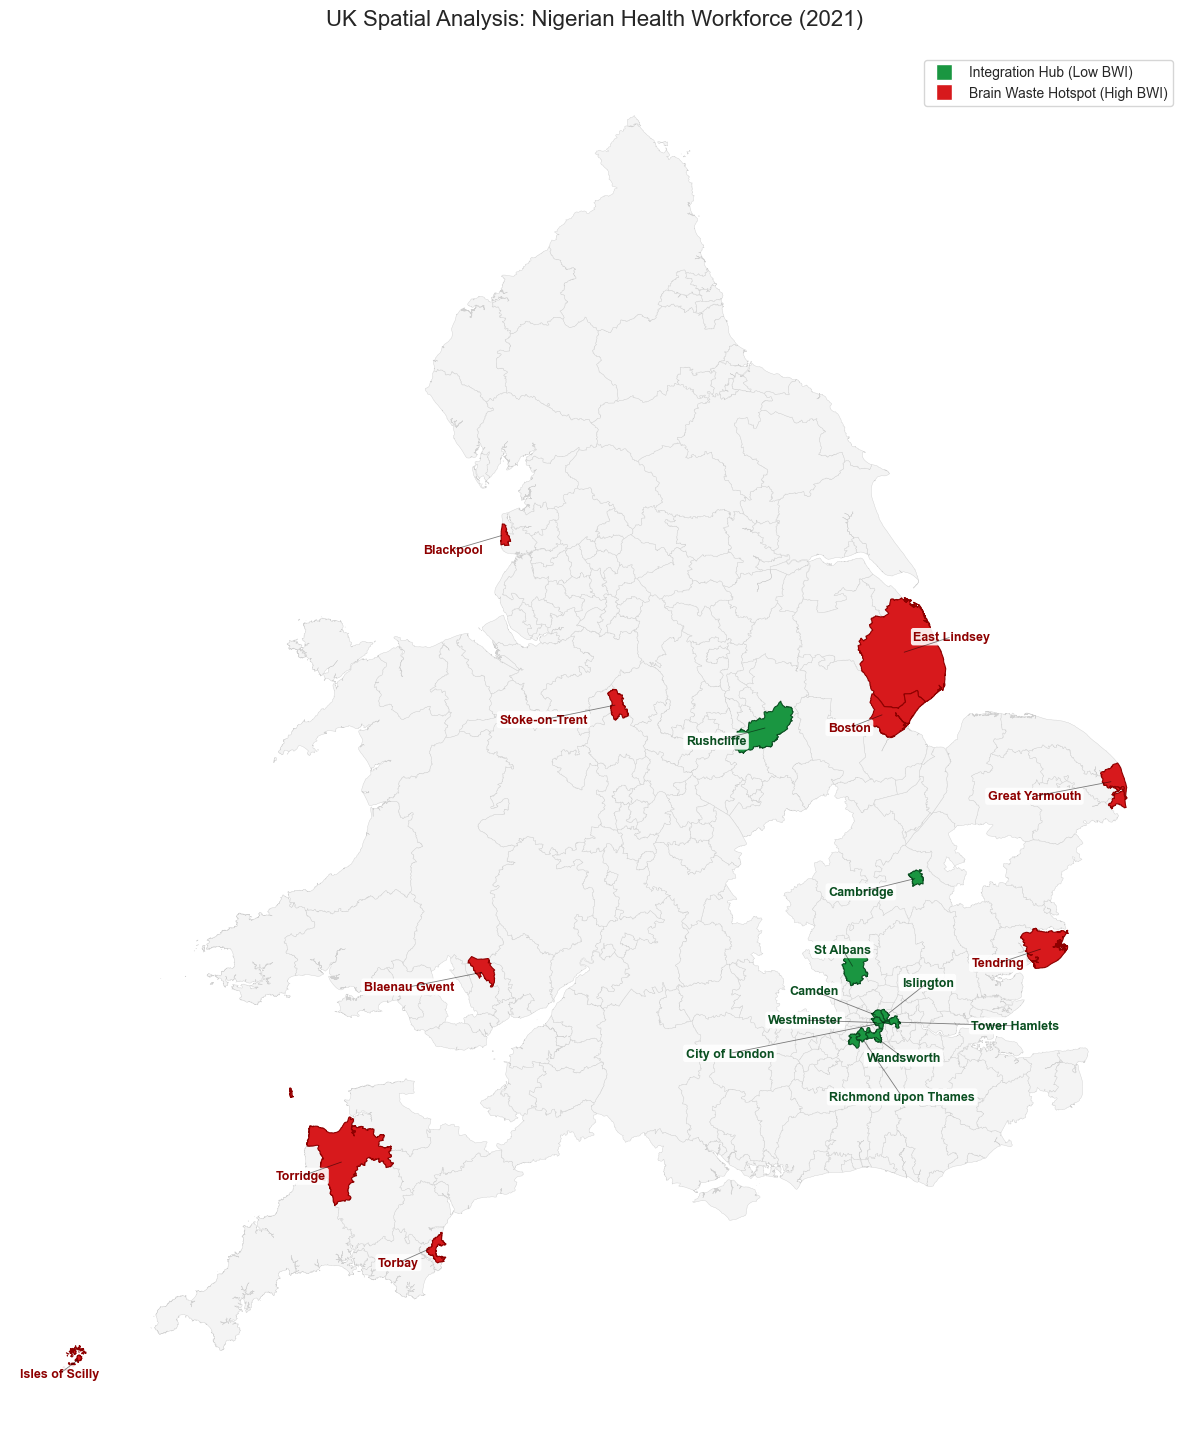

In [31]:
import geopandas as gpd
from matplotlib.lines import Line2D

# Setup paths
base_path = r'C:\Users\Nyikuri\OneDrive\Documents\DataScienceLab_Migration'
data_path = os.path.join(base_path, 'data_processed', 'named_nigeria_bw_2021.csv')
res_dir = os.path.join(base_path, 'results')
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# Load and Prepare Data
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    # Using GeoPandas to read the map file
    uk_map = gpd.read_file('https://raw.githubusercontent.com/martinjc/UK-GeoJSON/master/json/administrative/gb/lad.json').to_crs(epsg=4326)
    m = uk_map.merge(df, left_on='LAD13NM', right_on='area_name')
    hubs = m.nsmallest(10, 'bw_index').reset_index()
    spots = m.nlargest(10, 'bw_index').reset_index()

    # Create the Map
    fig, ax = plt.subplots(1, 1, figsize=(12, 16))
    m.plot(ax=ax, color='#f4f4f4', edgecolor='#d0d0d0', linewidth=0.3)
    hubs.plot(ax=ax, color='#1a9641', edgecolor='#0a4f21', linewidth=0.8)
    spots.plot(ax=ax, color='#d7191c', edgecolor='#8e0000', linewidth=0.8)

    # Improved Labeling using adjustText
    def add_labels_smart(gdf, ax, clr):
        texts = []
        points_x = []
        points_y = []

        for _, row in gdf.iterrows():
            c = row.geometry.representative_point().coords[0]
            points_x.append(c[0])
            points_y.append(c[1])

            t = ax.text(
                c[0], c[1],
                row['area_name'],
                fontsize=9,
                fontweight='bold',
                color=clr,
                ha='center',
                va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.9, ec='none')
            )
            texts.append(t)

        adjust_text(
            texts,
            x=points_x,
            y=points_y,
            ax=ax,
            expand=(1.5, 2.0),
            force_text=(0.8, 1.5),
            force_points=(0.5, 1.0),
            arrowprops=dict(
                arrowstyle='-',
                color='black',
                lw=0.6,
                alpha=0.5
            ),
            min_arrow_len=5,
            ensure_inside_axes=True
        )

    add_labels_smart(spots, ax, '#8e0000')
    add_labels_smart(hubs, ax, '#0a4f21')

    plt.title('UK Spatial Analysis: Nigerian Health Workforce (2021)', fontsize=16, pad=20)
    ax.set_axis_off()
    
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Integration Hub (Low BWI)',
               markerfacecolor='#1a9641', markersize=12),
        Line2D([0], [0], marker='s', color='w', label='Brain Waste Hotspot (High BWI)',
               markerfacecolor='#d7191c', markersize=12)
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()

    out_path = os.path.join(res_dir, 'visible_labeled_map.png')
    plt.savefig(out_path, dpi=300)
    plt.show()

Integration Hubs (Green) are concentrated in London and university cities, where robust healthcare infrastructure and professional networks facilitate high-skilled placement (BWI as low as 0.06).

Brain Waste Hotspots (Red) dominate post-industrial and coastal regions, where high indices (up to 0.55) suggest Nigerian health workers are disproportionately restricted to care-sector roles.
The clustering proves that "Brain Waste" is a localized systemic issue rather than a factor of community size.